# 🏦 Loan Approval Prediction Using Machine Learning

---

**Objective:** Build a Machine Learning model to predict whether a loan application will be **Approved** or **Rejected**.

## 📦 Import Libraries

In [40]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)
import xgboost as xgb
import joblib
import os

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📋 TASK 1: Dataset Understanding

In [41]:
df = pd.read_csv('../data/loan_approval_dataset.csv')
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

print(f'✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded: 4269 rows × 13 columns


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [42]:
# Identify feature types
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print(f'🔢 Numerical Features ({len(numerical_features)}): {numerical_features}')
print(f'🔤 Categorical Features ({len(categorical_features)}): {categorical_features}')

🔢 Numerical Features (10): ['loan_id', 'no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
🔤 Categorical Features (3): ['education', 'self_employed', 'loan_status']


In [43]:
# Dataset info
print('📊 Data Types:')
df.info()

📊 Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [44]:
# Missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('✅ No missing values found!')
else:
    print('⚠️ Missing Values:')
    print(missing_df)

✅ No missing values found!


In [45]:
# Statistical summary
print('📈 Statistical Summary:')
df.describe().round(2)

📈 Statistical Summary:


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.0,4269.0,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2135.0,2.5,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1232.5,1.7,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,1.0,0.0,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1068.0,1.0,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,2135.0,3.0,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,3202.0,4.0,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,4269.0,5.0,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [46]:
# Target variable
target_col = 'loan_status'
print(f'🎯 Target Variable: {target_col}')
print(f'Classes: {df[target_col].unique()}')
print(f'\nDistribution:')
print(df[target_col].value_counts())
print(f'\nBalance (%):')
print((df[target_col].value_counts(normalize=True)*100).round(2))

🎯 Target Variable: loan_status
Classes: ['Approved' 'Rejected']

Distribution:
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

Balance (%):
loan_status
Approved    62.22
Rejected    37.78
Name: proportion, dtype: float64


---
## 📊 TASK 2: Exploratory Data Analysis (EDA)
### 2A. Univariate Analysis

In [47]:
# Detect key columns
income_col = next((c for c in df.columns if 'income' in c.lower()), None)
loan_amt_col = next((c for c in df.columns if 'loan_amount' in c.lower()), None)
cibil_col = next((c for c in df.columns if 'cibil' in c.lower() or 'credit_score' in c.lower()), None)
term_col = next((c for c in df.columns if 'term' in c.lower()), None)
edu_col = next((c for c in df.columns if 'education' in c.lower()), None)
emp_col = next((c for c in df.columns if 'self_employed' in c.lower() or 'employ' in c.lower()), None)
dep_col = next((c for c in df.columns if 'dependent' in c.lower()), None)

print('Detected columns:')
print(f'  Income:      {income_col}')
print(f'  Loan Amount: {loan_amt_col}')
print(f'  CIBIL Score: {cibil_col}')
print(f'  Loan Term:   {term_col}')
print(f'  Education:   {edu_col}')
print(f'  Employment:  {emp_col}')
print(f'  Dependents:  {dep_col}')

Detected columns:
  Income:      income_annum
  Loan Amount: loan_amount
  CIBIL Score: cibil_score
  Loan Term:   loan_term
  Education:   education
  Employment:  self_employed
  Dependents:  no_of_dependents


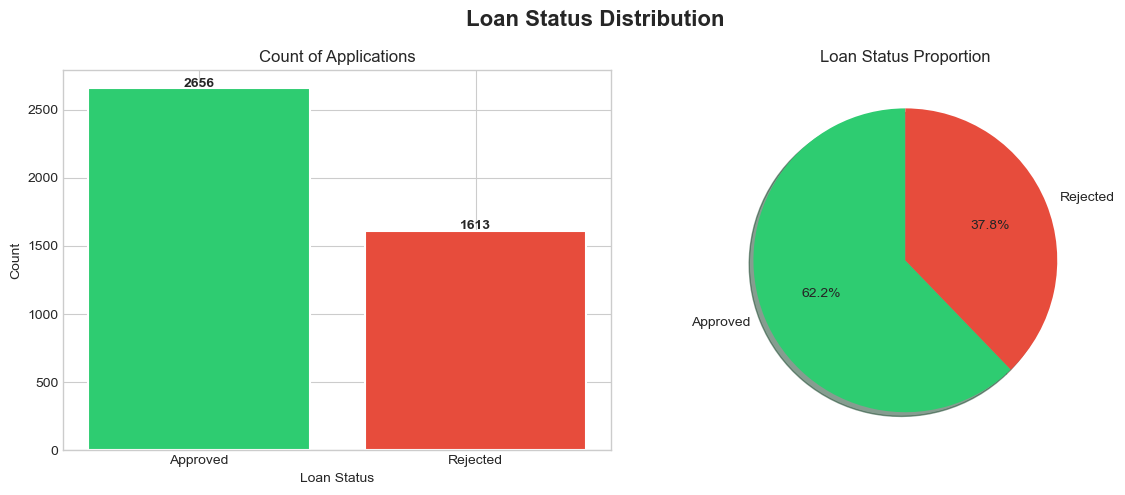

📝 Observation: Check if data is balanced or imbalanced between Approved and Rejected classes.


In [48]:
# Plot 1: Loan Status Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Loan Status Distribution', fontsize=16, fontweight='bold')

counts = df[target_col].value_counts()
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Count of Applications')
axes[0].set_xlabel('Loan Status'); axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, colors=colors, autopct='%1.1f%%', startangle=90, shadow=True)
axes[1].set_title('Loan Status Proportion')

plt.tight_layout(); plt.show()
print('📝 Observation: Check if data is balanced or imbalanced between Approved and Rejected classes.')

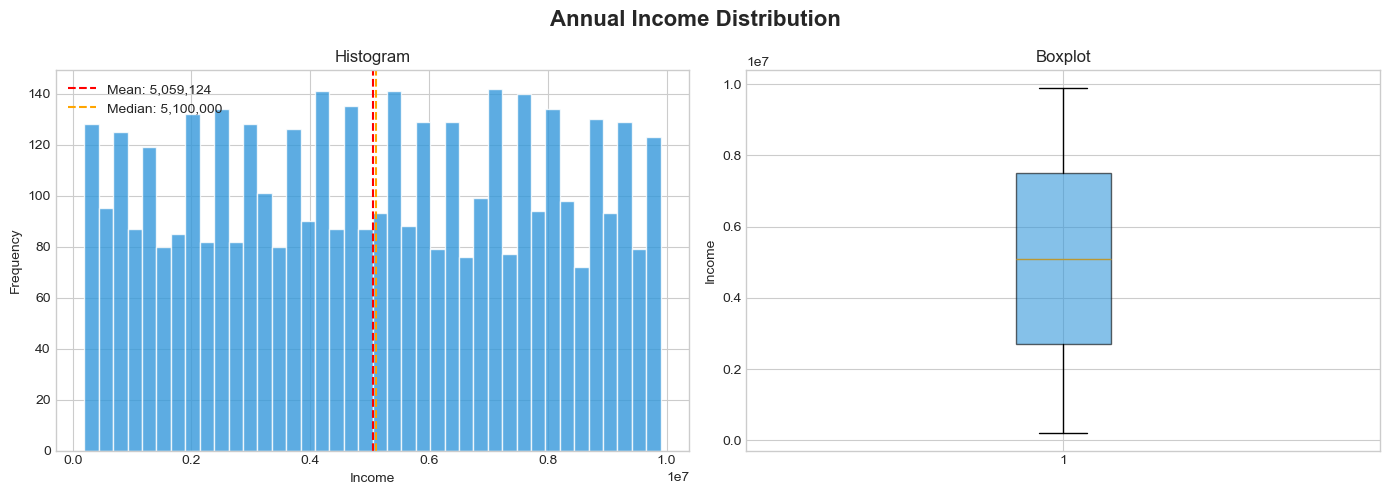

📝 Observation: Income is right-skewed. Most applicants have moderate income; a few very high earners pull the mean up.


In [49]:
# Plot 2: Income Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Annual Income Distribution', fontsize=16, fontweight='bold')

axes[0].hist(df[income_col], bins=40, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(df[income_col].mean(), color='red', linestyle='--', label=f'Mean: {df[income_col].mean():,.0f}')
axes[0].axvline(df[income_col].median(), color='orange', linestyle='--', label=f'Median: {df[income_col].median():,.0f}')
axes[0].set_title('Histogram'); axes[0].set_xlabel('Income'); axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot(df[income_col], patch_artist=True, boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[1].set_title('Boxplot'); axes[1].set_ylabel('Income')

plt.tight_layout(); plt.show()
print('📝 Observation: Income is right-skewed. Most applicants have moderate income; a few very high earners pull the mean up.')

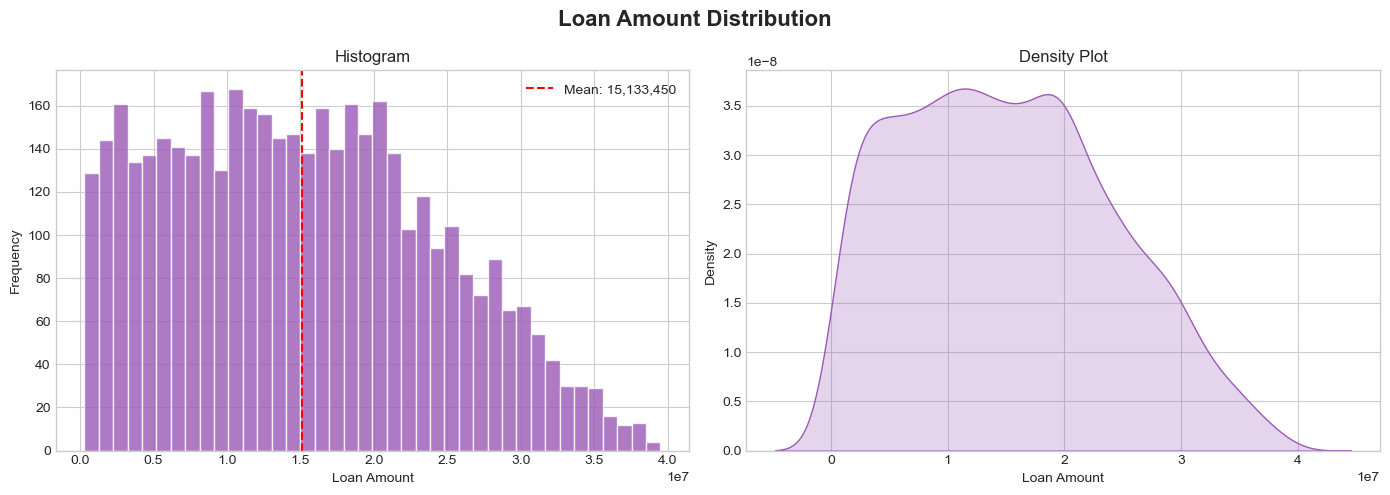

📝 Observation: Loan amounts are spread across a range with some high-value outliers present.


In [50]:
# Plot 3: Loan Amount Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Loan Amount Distribution', fontsize=16, fontweight='bold')

axes[0].hist(df[loan_amt_col], bins=40, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[0].axvline(df[loan_amt_col].mean(), color='red', linestyle='--', label=f'Mean: {df[loan_amt_col].mean():,.0f}')
axes[0].set_title('Histogram'); axes[0].set_xlabel('Loan Amount'); axes[0].set_ylabel('Frequency')
axes[0].legend()

sns.kdeplot(df[loan_amt_col], ax=axes[1], fill=True, color='#9b59b6')
axes[1].set_title('Density Plot'); axes[1].set_xlabel('Loan Amount')

plt.tight_layout(); plt.show()
print('📝 Observation: Loan amounts are spread across a range with some high-value outliers present.')

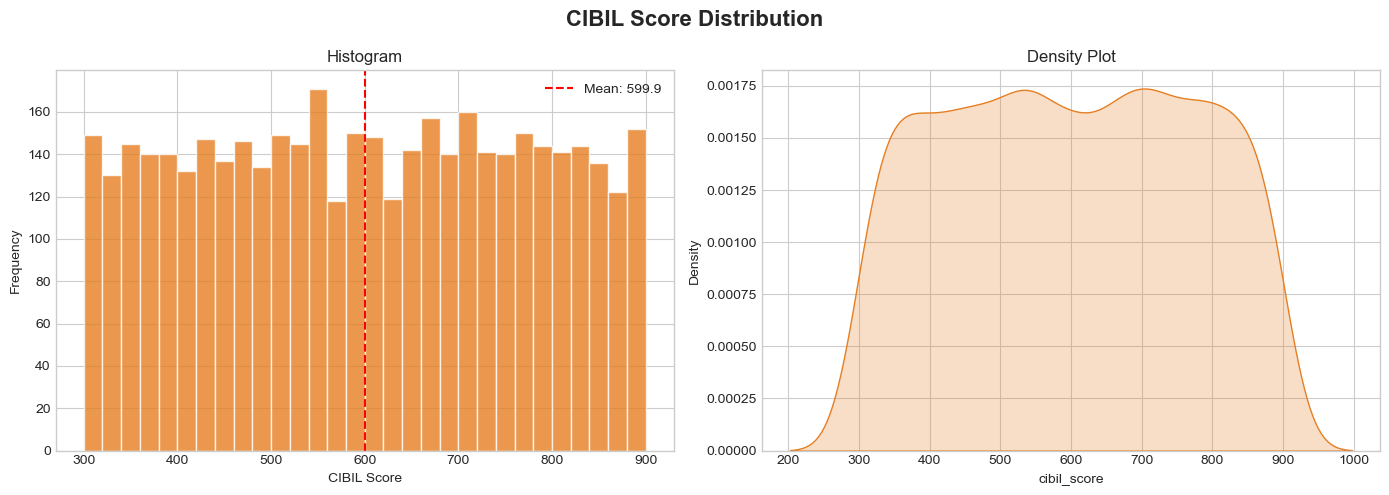

📝 Observation: CIBIL scores show a bimodal or spread distribution — a key predictor of creditworthiness.


In [51]:
# Plot 4: CIBIL Score Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CIBIL Score Distribution', fontsize=16, fontweight='bold')

axes[0].hist(df[cibil_col], bins=30, color='#e67e22', edgecolor='white', alpha=0.8)
axes[0].axvline(df[cibil_col].mean(), color='red', linestyle='--', label=f'Mean: {df[cibil_col].mean():.1f}')
axes[0].set_title('Histogram'); axes[0].set_xlabel('CIBIL Score'); axes[0].set_ylabel('Frequency')
axes[0].legend()

sns.kdeplot(df[cibil_col], ax=axes[1], fill=True, color='#e67e22')
axes[1].set_title('Density Plot')

plt.tight_layout(); plt.show()
print('📝 Observation: CIBIL scores show a bimodal or spread distribution — a key predictor of creditworthiness.')

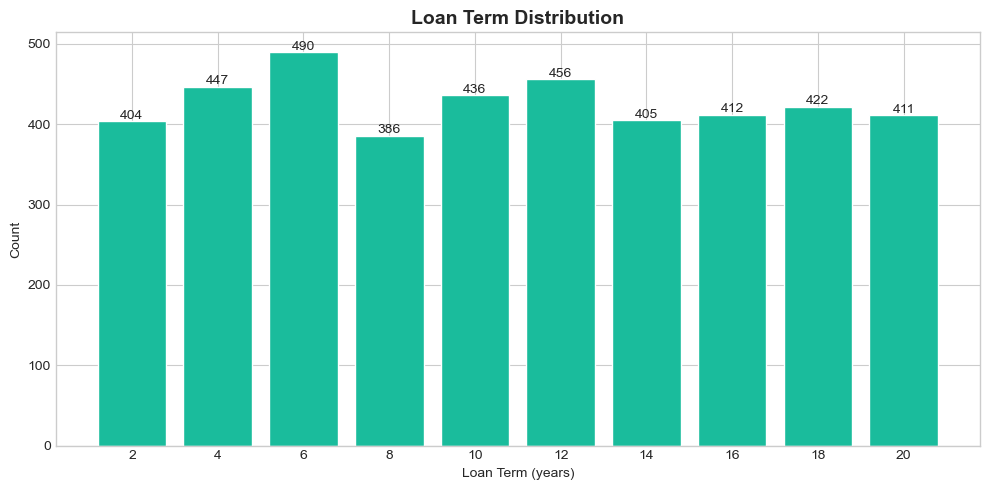

📝 Observation: Some loan terms are more frequently chosen by applicants than others.


In [52]:
# Plot 5: Loan Term Distribution
fig, ax = plt.subplots(figsize=(10, 5))
term_counts = df[term_col].value_counts().sort_index()
ax.bar(term_counts.index.astype(str), term_counts.values, color='#1abc9c', edgecolor='white')
ax.set_title('Loan Term Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Loan Term (years)'); ax.set_ylabel('Count')
for i, v in enumerate(term_counts.values):
    ax.text(i, v + 3, str(v), ha='center')
plt.tight_layout(); plt.show()
print('📝 Observation: Some loan terms are more frequently chosen by applicants than others.')

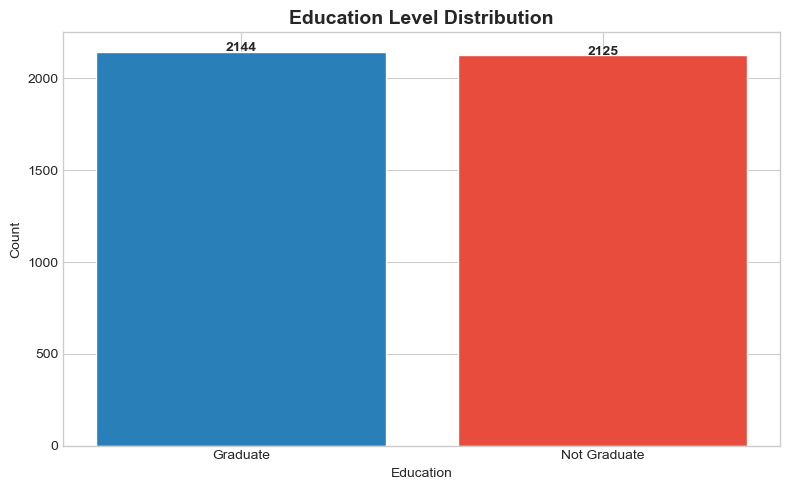

📝 Observation: Shows the split between Graduate and Not Graduate applicants in the dataset.


In [53]:
# Plot 6: Education Distribution
fig, ax = plt.subplots(figsize=(8, 5))
edu_counts = df[edu_col].value_counts()
bars = ax.bar(edu_counts.index, edu_counts.values, color=['#2980b9', '#e74c3c'], edgecolor='white')
ax.set_title('Education Level Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Education'); ax.set_ylabel('Count')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', fontweight='bold')
plt.tight_layout(); plt.show()
print('📝 Observation: Shows the split between Graduate and Not Graduate applicants in the dataset.')

### 2B. Bivariate Analysis

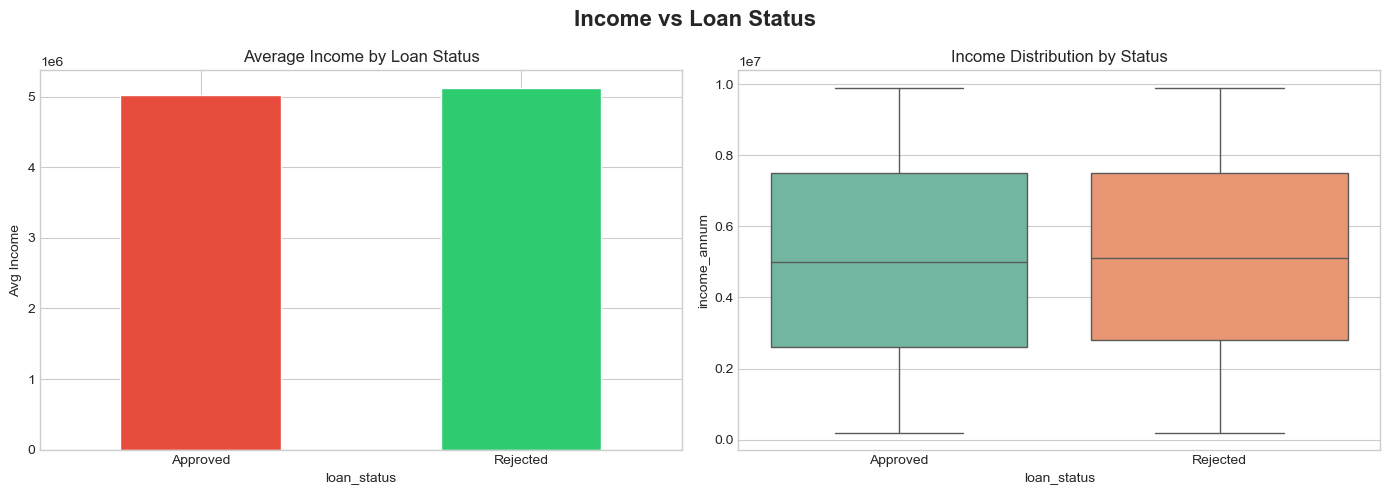

📝 Observation: Approved applicants generally have higher incomes. Income is a meaningful predictor.


In [54]:
# Income vs Loan Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Income vs Loan Status', fontsize=16, fontweight='bold')

df.groupby(target_col)[income_col].mean().plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='white', rot=0)
axes[0].set_title('Average Income by Loan Status'); axes[0].set_ylabel('Avg Income')

sns.boxplot(data=df, x=target_col, y=income_col, ax=axes[1], palette='Set2')
axes[1].set_title('Income Distribution by Status')

plt.tight_layout(); plt.show()
print('📝 Observation: Approved applicants generally have higher incomes. Income is a meaningful predictor.')

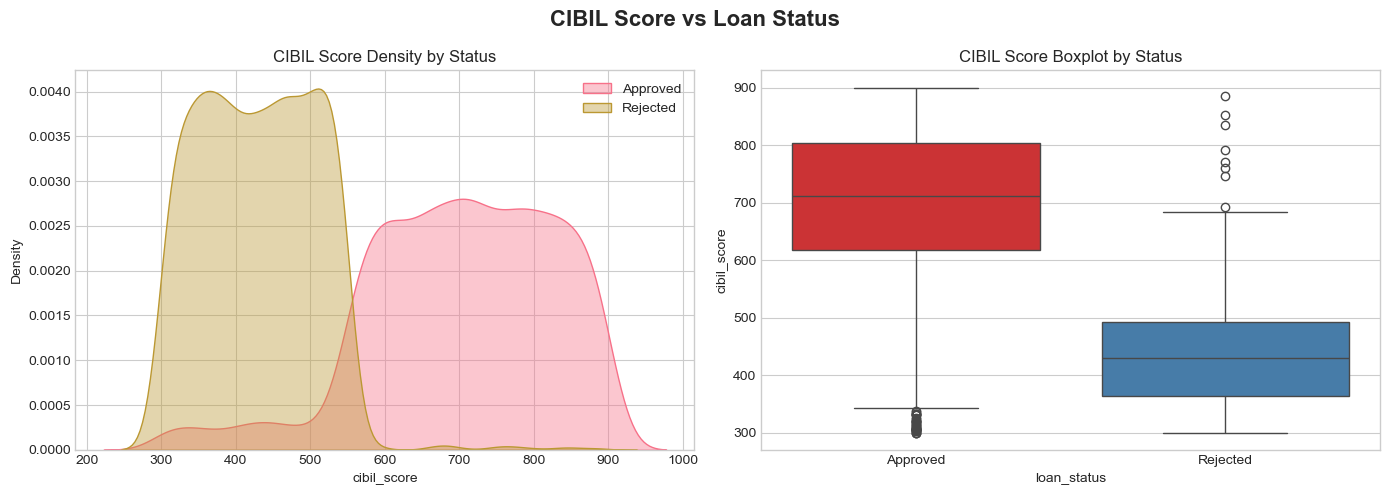

📝 Observation: Clear and strong separation — approved applicants have significantly higher CIBIL scores. This is the strongest predictor.


In [55]:
# CIBIL Score vs Loan Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CIBIL Score vs Loan Status', fontsize=16, fontweight='bold')

for status in df[target_col].unique():
    subset = df[df[target_col] == status][cibil_col]
    sns.kdeplot(subset, ax=axes[0], label=status, fill=True, alpha=0.4)
axes[0].set_title('CIBIL Score Density by Status'); axes[0].legend()

sns.boxplot(data=df, x=target_col, y=cibil_col, ax=axes[1], palette='Set1')
axes[1].set_title('CIBIL Score Boxplot by Status')

plt.tight_layout(); plt.show()
print('📝 Observation: Clear and strong separation — approved applicants have significantly higher CIBIL scores. This is the strongest predictor.')

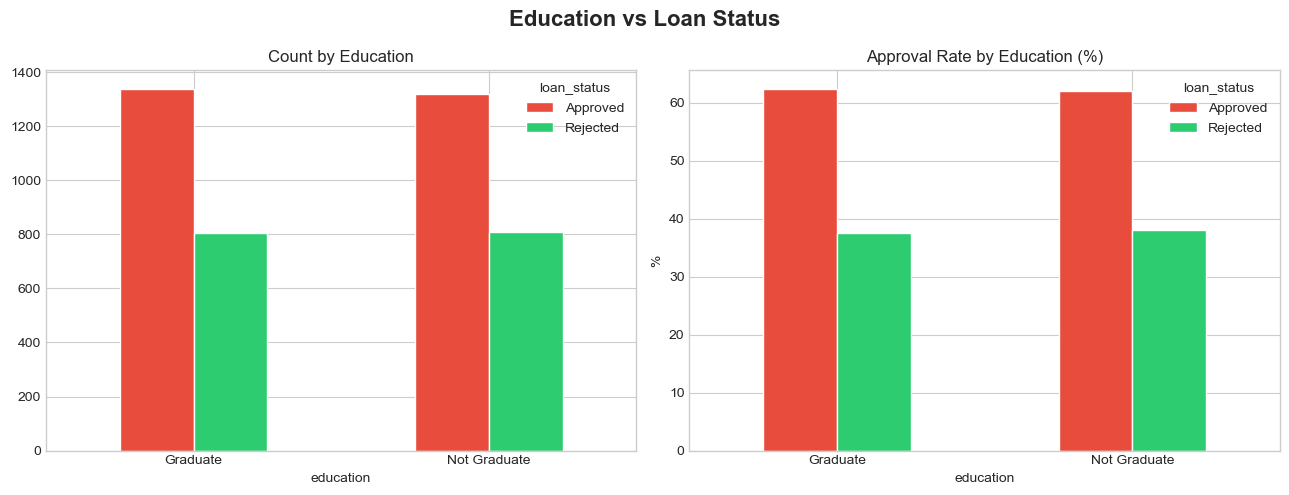

📝 Observation: Graduates tend to have a slightly higher loan approval rate than non-graduates.


In [56]:
# Education vs Loan Status
ct_edu = pd.crosstab(df[edu_col], df[target_col])
ct_edu_pct = ct_edu.div(ct_edu.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Education vs Loan Status', fontsize=16, fontweight='bold')
ct_edu.plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='white', rot=0)
axes[0].set_title('Count by Education')
ct_edu_pct.plot(kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71'], edgecolor='white', rot=0)
axes[1].set_title('Approval Rate by Education (%)'); axes[1].set_ylabel('%')
plt.tight_layout(); plt.show()
print('📝 Observation: Graduates tend to have a slightly higher loan approval rate than non-graduates.')

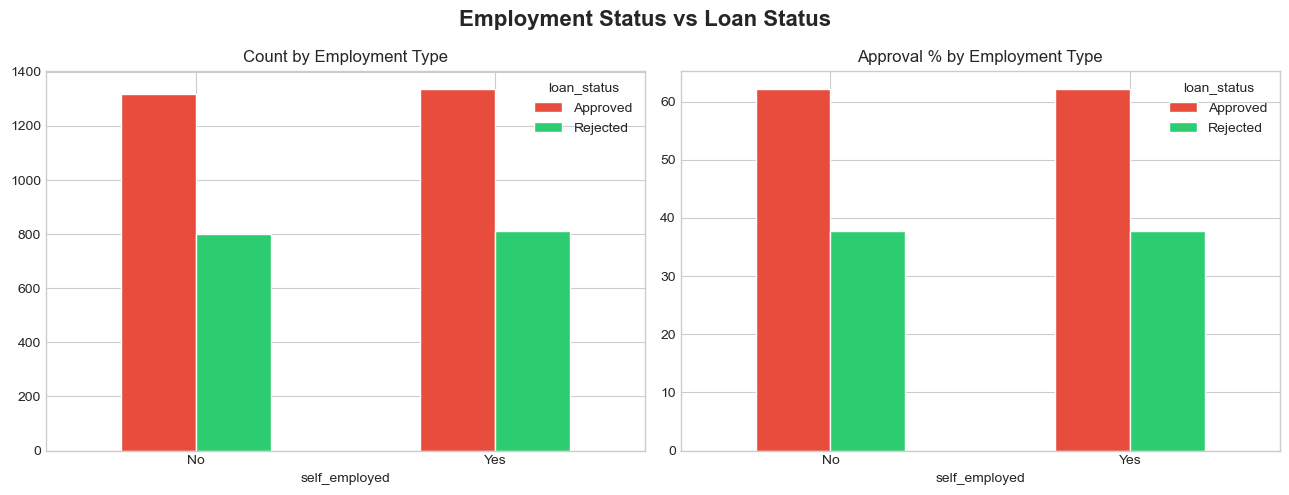

📝 Observation: Self-employed and salaried applicants show different approval patterns.


In [57]:
# Self-Employed vs Loan Status
ct_emp = pd.crosstab(df[emp_col], df[target_col])
ct_emp_pct = ct_emp.div(ct_emp.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Employment Status vs Loan Status', fontsize=16, fontweight='bold')
ct_emp.plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='white', rot=0)
axes[0].set_title('Count by Employment Type')
ct_emp_pct.plot(kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71'], edgecolor='white', rot=0)
axes[1].set_title('Approval % by Employment Type')
plt.tight_layout(); plt.show()
print('📝 Observation: Self-employed and salaried applicants show different approval patterns.')

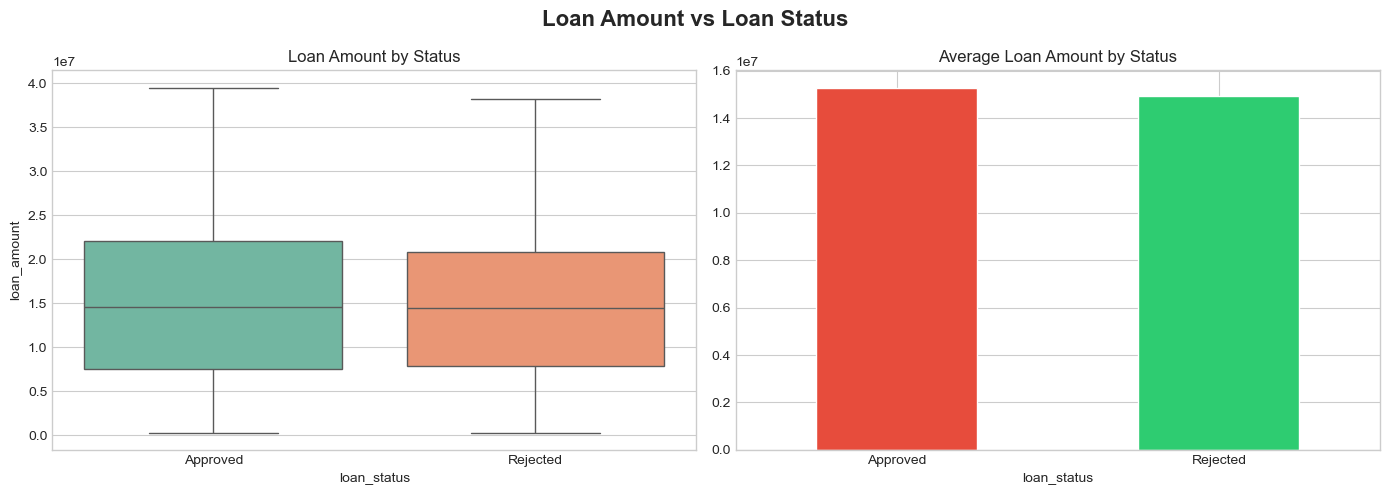

📝 Observation: Loan amount alone is not the strongest differentiator — both groups request varying amounts.


In [58]:
# Loan Amount vs Loan Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Loan Amount vs Loan Status', fontsize=16, fontweight='bold')
sns.boxplot(data=df, x=target_col, y=loan_amt_col, ax=axes[0], palette='Set2')
axes[0].set_title('Loan Amount by Status')
df.groupby(target_col)[loan_amt_col].mean().plot(kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71'], edgecolor='white', rot=0)
axes[1].set_title('Average Loan Amount by Status')
plt.tight_layout(); plt.show()
print('📝 Observation: Loan amount alone is not the strongest differentiator — both groups request varying amounts.')

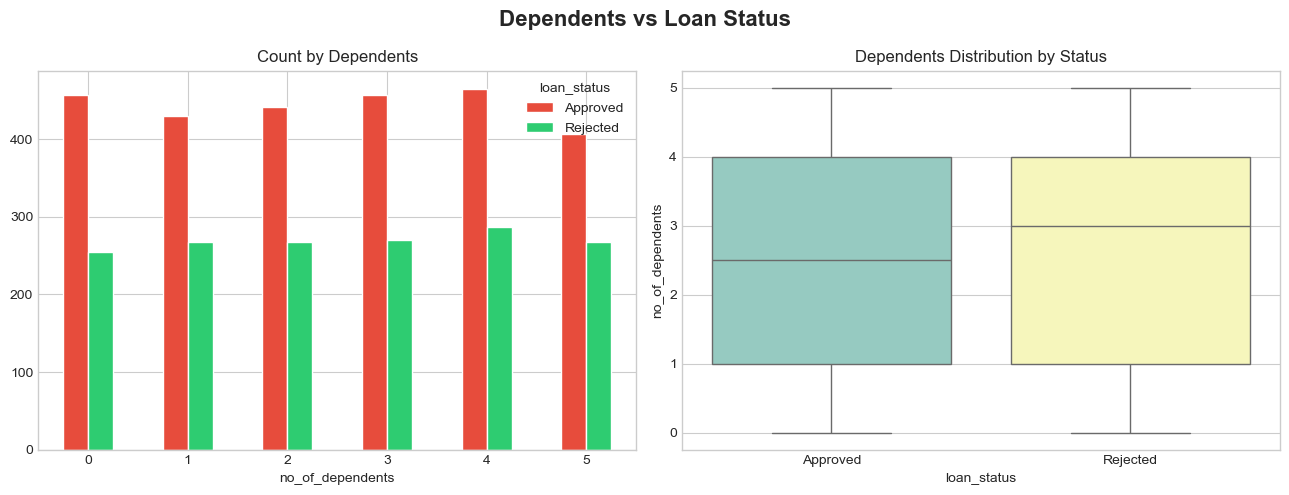

📝 Observation: Number of dependents has a mild effect on loan outcomes.


In [59]:
# Dependents vs Loan Status
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Dependents vs Loan Status', fontsize=16, fontweight='bold')
ct_dep = pd.crosstab(df[dep_col], df[target_col])
ct_dep.plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='white', rot=0)
axes[0].set_title('Count by Dependents')
sns.boxplot(data=df, x=target_col, y=dep_col, ax=axes[1], palette='Set3')
axes[1].set_title('Dependents Distribution by Status')
plt.tight_layout(); plt.show()
print('📝 Observation: Number of dependents has a mild effect on loan outcomes.')

### 2C. Multivariate Analysis

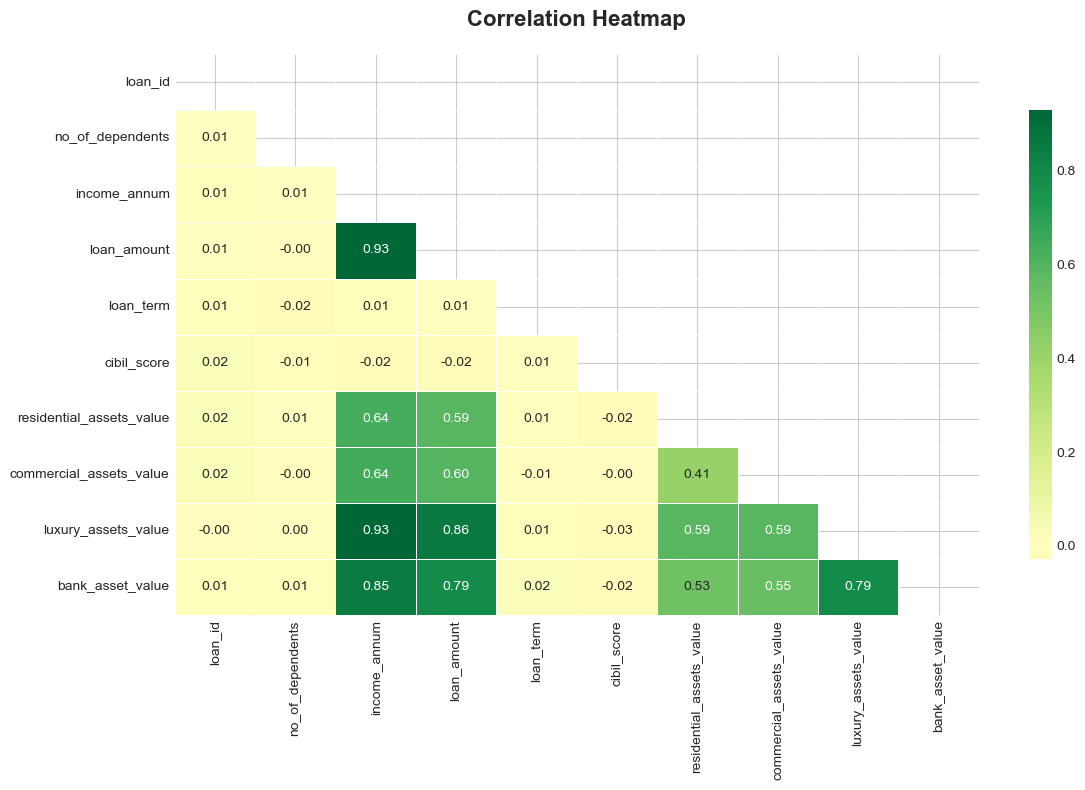

📝 Observation: CIBIL score and assets show strong correlation with loan approval.


In [60]:
# Correlation Heatmap
num_df = df.select_dtypes(include=['int64','float64'])
fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(num_df.corr(), dtype=bool))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, center=0, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout(); plt.show()
print('📝 Observation: CIBIL score and assets show strong correlation with loan approval.')

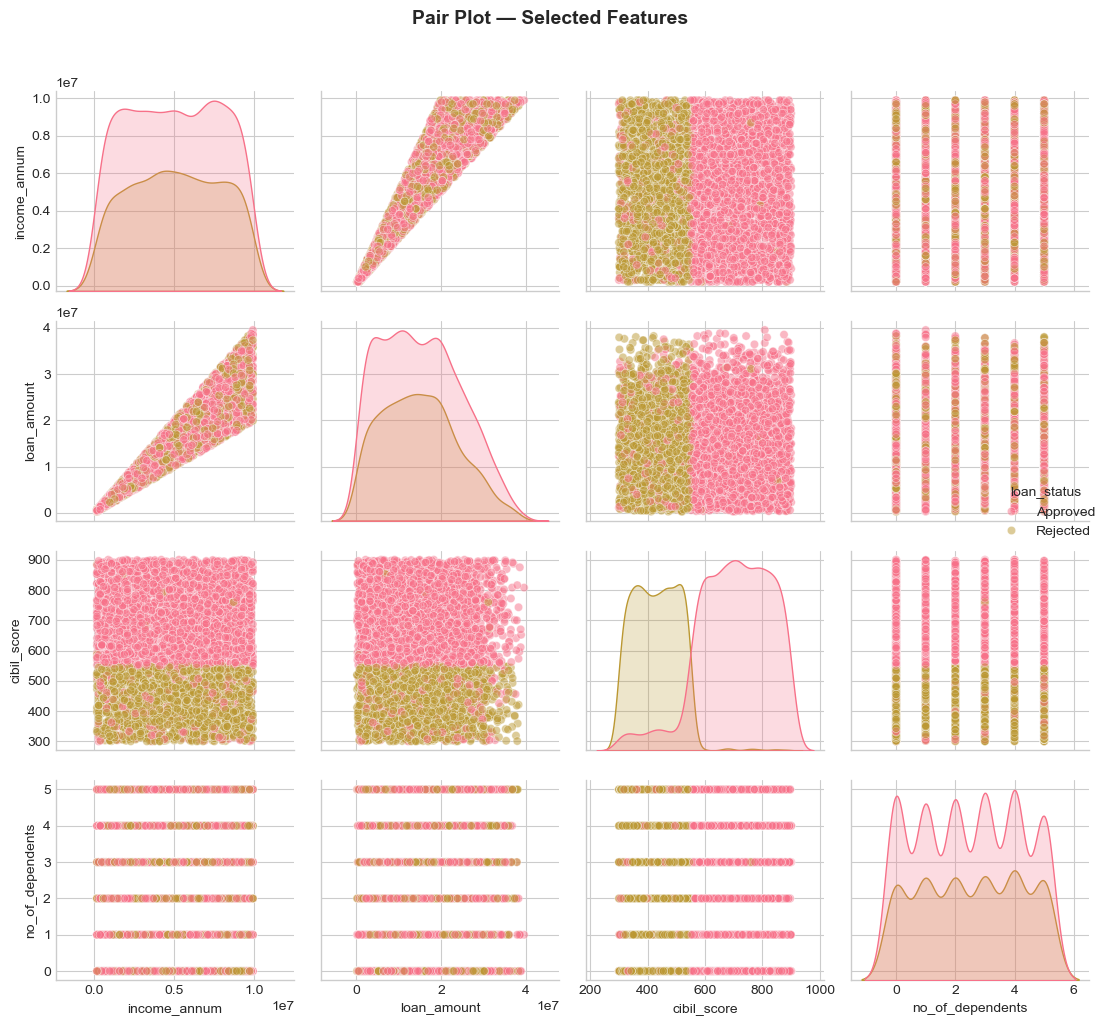

📝 Observation: CIBIL score shows the clearest visual separation between approved and rejected classes.


In [62]:
# Pair Plot
selected = [c for c in [income_col, loan_amt_col, cibil_col, dep_col, target_col] if c]
g = sns.pairplot(df[selected], hue=target_col, plot_kws={'alpha': 0.5}, diag_kind='kde')
g.fig.suptitle('Pair Plot — Selected Features', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('📝 Observation: CIBIL score shows the clearest visual separation between approved and rejected classes.')

### 2D. Insights from EDA

***KEY INSIGHTS FROM EDA
=====================

1. Strongest Predictors:
   -> CIBIL Score (clearest separation between classes)
   -> Annual Income (approved applicants earn more)
   -> Total Assets (higher assets = more likely approved)

2. CIBIL Score Analysis:
   -> YES, higher CIBIL score strongly increases approval chances
   -> Clear density separation visible in KDE plot

3. Income Influence:
   -> YES, income positively influences approval
   -> Approved applicants have noticeably higher average income

4. Assets Impact:
   -> Higher assets correlate with approvals
   -> Act as financial security for the lending institution

5. Other Observations:
   -> Graduates show marginally better approval rates
   -> Self-employment vs salaried has minor influence
   -> Number of dependents has low predictive power


---
## 🔧 TASK 3: Data Preprocessing

In [64]:
df_processed = df.copy()

# Drop ID columns
id_cols = [c for c in df_processed.columns if c.lower() in ['loan_id', 'id', ' loan_id']]
if id_cols:
    df_processed.drop(columns=id_cols, inplace=True)
    print(f'Dropped ID columns: {id_cols}')

# Check duplicates
dups = df_processed.duplicated().sum()
print(f'Duplicate rows: {dups}')
if dups > 0:
    df_processed.drop_duplicates(inplace=True)

print(f'Shape after cleaning: {df_processed.shape}')

Dropped ID columns: ['loan_id']
Duplicate rows: 0
Shape after cleaning: (4269, 12)


In [65]:
# Label Encoding
le = LabelEncoder()
cat_cols = df_processed.select_dtypes(include='object').columns.tolist()
label_maps = {}
for col in cat_cols:
    df_processed[col] = le.fit_transform(df_processed[col])
    label_maps[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'✓ {col}: {label_maps[col]}')

✓ education: {'Graduate': np.int64(0), 'Not Graduate': np.int64(1)}
✓ self_employed: {'No': np.int64(0), 'Yes': np.int64(1)}
✓ loan_status: {'Approved': np.int64(0), 'Rejected': np.int64(1)}


In [66]:
# Features and target
X = df_processed.drop(columns=[target_col])
y = df_processed[target_col]
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Features: {list(X.columns)}')

X shape: (4269, 11)
y shape: (4269,)
Features: ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [67]:
# Train-test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print(f'Train class dist:\n{y_train.value_counts()}')

Train: 3415 samples | Test: 854 samples
Train class dist:
loan_status
0    2125
1    1290
Name: count, dtype: int64


In [68]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('✅ Scaling complete.')

✅ Scaling complete.


---
## 🤖 TASK 4: Model Building

In [69]:
# 1. Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=500)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
print('✅ Logistic Regression trained')

✅ Logistic Regression trained


In [70]:
# 2. Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=8)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print('✅ Decision Tree trained')

✅ Decision Tree trained


In [71]:
# 3. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print('✅ Random Forest trained')

✅ Random Forest trained


In [72]:
# 4. XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print('✅ XGBoost trained')

✅ XGBoost trained


In [73]:
# 5. KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
print('✅ KNN trained')

print('\n🎉 All 5 models trained!')

✅ KNN trained

🎉 All 5 models trained!


---
## 📈 TASK 5: Model Evaluation

In [74]:
def evaluate(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy':  round(accuracy_score(y_true, y_pred)*100, 2),
        'Precision': round(precision_score(y_true, y_pred, average='weighted')*100, 2),
        'Recall':    round(recall_score(y_true, y_pred, average='weighted')*100, 2),
        'F1-Score':  round(f1_score(y_true, y_pred, average='weighted')*100, 2),
    }

results = pd.DataFrame([
    evaluate('Logistic Regression', y_test, lr_pred),
    evaluate('Decision Tree',       y_test, dt_pred),
    evaluate('Random Forest',       y_test, rf_pred),
    evaluate('XGBoost',             y_test, xgb_pred),
    evaluate('KNN',                 y_test, knn_pred),
]).set_index('Model')

print('MODEL COMPARISON TABLE (values in %)')
print('='*60)
print(results.to_string())
print('='*60)
print(f'\n🏆 Best Model: {results["Accuracy"].idxmax()} — {results["Accuracy"].max():.2f}%')

MODEL COMPARISON TABLE (values in %)
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression     92.27      92.25   92.27     92.24
Decision Tree           97.89      97.93   97.89     97.88
Random Forest           98.36      98.37   98.36     98.36
XGBoost                 98.01      98.01   98.01     98.00
KNN                     89.70      89.66   89.70     89.66

🏆 Best Model: Random Forest — 98.36%


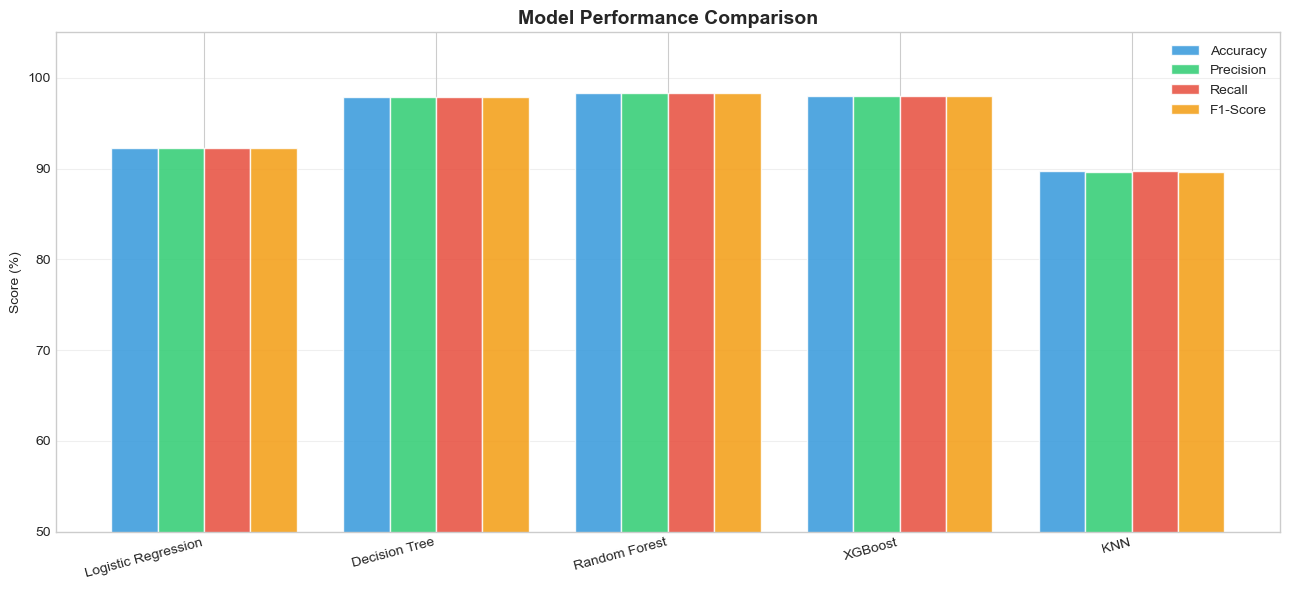

In [75]:
# Visual comparison
metrics = ['Accuracy','Precision','Recall','F1-Score']
x = np.arange(len(results))
width = 0.2
colors_bar = ['#3498db','#2ecc71','#e74c3c','#f39c12']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (m, c) in enumerate(zip(metrics, colors_bar)):
    ax.bar(x + i*width, results[m], width, label=m, color=c, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(results.index, rotation=15, ha='right')
ax.set_ylabel('Score (%)'); ax.set_ylim(50, 105)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

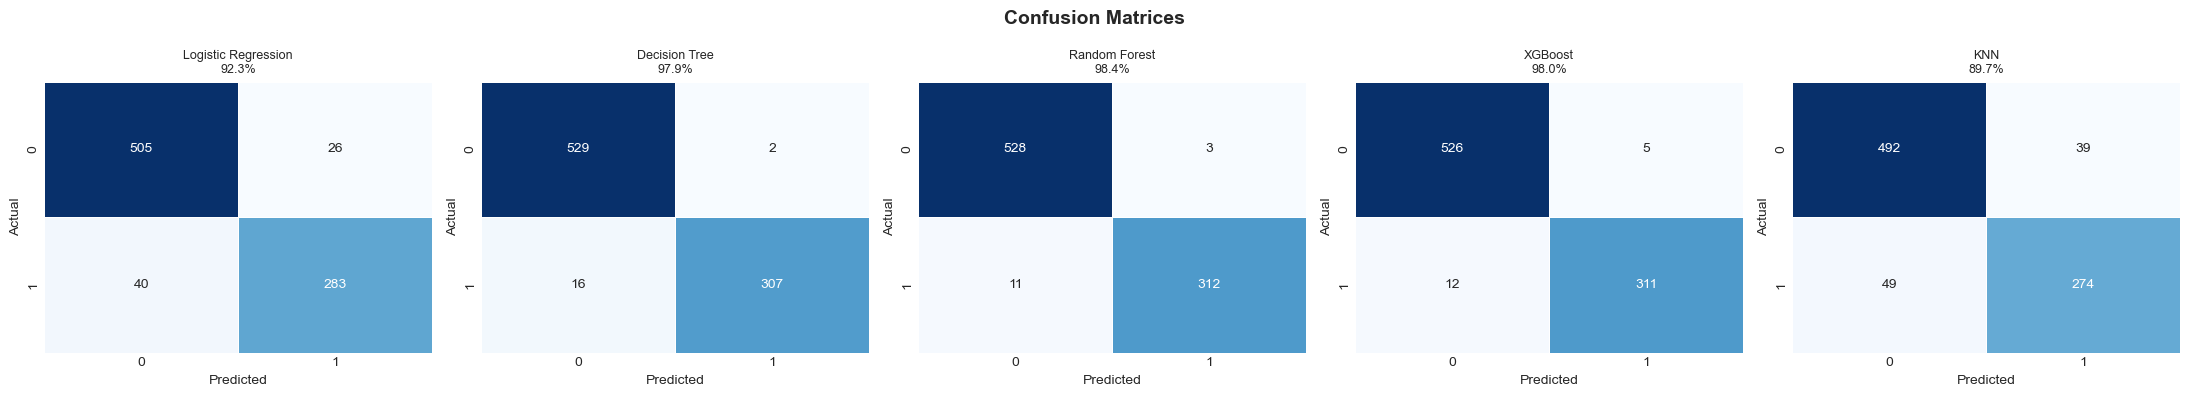

In [76]:
# Confusion matrices
model_preds = [('Logistic Regression',lr_pred),('Decision Tree',dt_pred),
               ('Random Forest',rf_pred),('XGBoost',xgb_pred),('KNN',knn_pred)]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for ax, (name, pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False, linewidths=0.5)
    ax.set_title(f'{name}\n{accuracy_score(y_test,pred)*100:.1f}%', fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout(); plt.show()

In [77]:
# Detailed report for best model
best_name = results['Accuracy'].idxmax()
pred_map = dict(model_preds)
print(f'Classification Report — {best_name}')
print('='*50)
print(classification_report(y_test, pred_map[best_name]))

Classification Report — Random Forest
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       531
           1       0.99      0.97      0.98       323

    accuracy                           0.98       854
   macro avg       0.99      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



---
## 🔍 TASK 6: Feature Importance Analysis

In [78]:
fi_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance (RF)': rf.feature_importances_,
    'Importance (XGB)': xgb_model.feature_importances_
}).sort_values('Importance (RF)', ascending=False).reset_index(drop=True)

print('Feature Importance Rankings:')
print(fi_df.to_string(index=False))

Feature Importance Rankings:
                 Feature  Importance (RF)  Importance (XGB)
             cibil_score         0.801152          0.684262
               loan_term         0.064358          0.201328
             loan_amount         0.030672          0.025325
            income_annum         0.020317          0.026189
     luxury_assets_value         0.019399          0.009623
 commercial_assets_value         0.018403          0.011408
residential_assets_value         0.017593          0.009684
        bank_asset_value         0.015068          0.009492
        no_of_dependents         0.007783          0.007791
           self_employed         0.002866          0.009094
               education         0.002389          0.005805


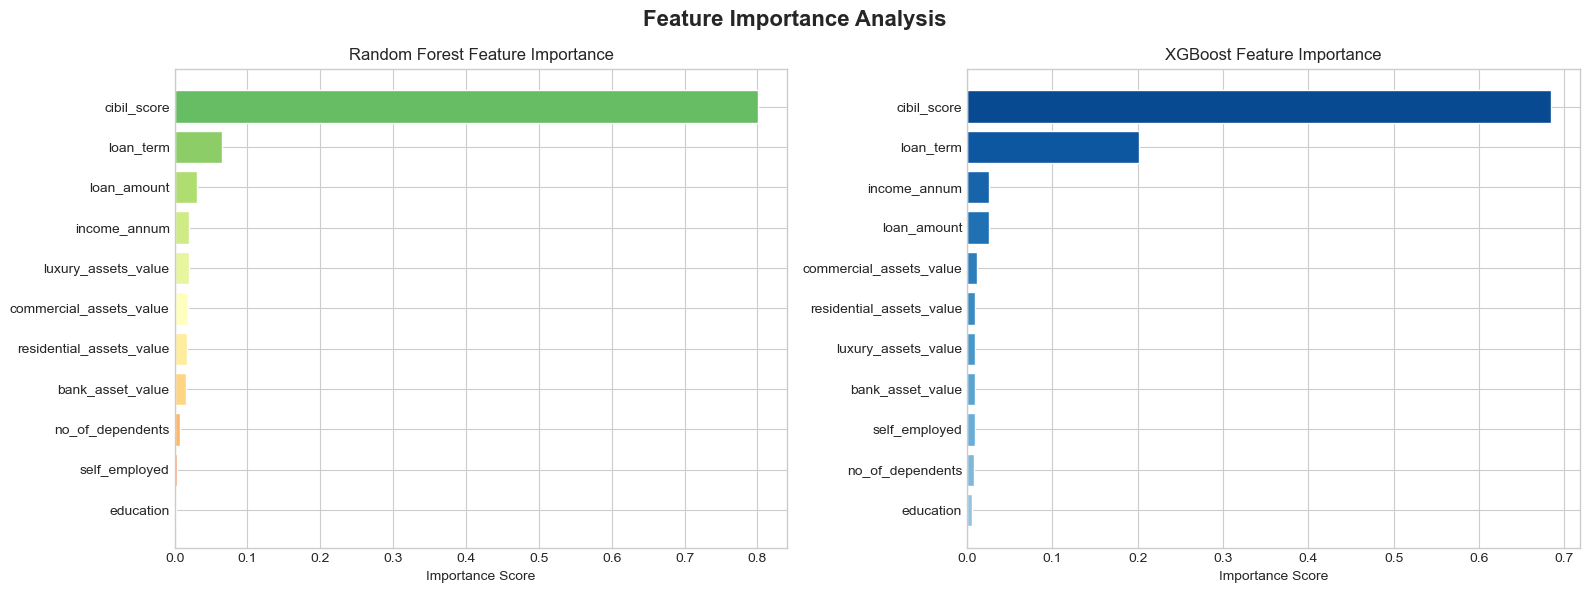

Top 3 features: ['cibil_score', 'loan_term', 'loan_amount']
These drive the model decisions most strongly.


In [79]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance Analysis', fontsize=16, fontweight='bold')

colors_fi = plt.cm.RdYlGn(np.linspace(0.8, 0.2, len(fi_df)))
axes[0].barh(fi_df['Feature'], fi_df['Importance (RF)'], color=colors_fi, edgecolor='white')
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_xlabel('Importance Score')
axes[0].invert_yaxis()

fi_xgb = fi_df.sort_values('Importance (XGB)', ascending=False)
colors_fi2 = plt.cm.Blues(np.linspace(0.9, 0.4, len(fi_xgb)))
axes[1].barh(fi_xgb['Feature'], fi_xgb['Importance (XGB)'], color=colors_fi2, edgecolor='white')
axes[1].set_title('XGBoost Feature Importance')
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()

plt.tight_layout()
os.makedirs('../models', exist_ok=True)
plt.savefig('../models/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

top3 = fi_df['Feature'].head(3).tolist()
print(f'Top 3 features: {top3}')
print('These drive the model decisions most strongly.')

In [80]:
# Save best model and artifacts
best_obj = dict(zip(
    ['Logistic Regression','Decision Tree','Random Forest','XGBoost','KNN'],
    [lr, dt, rf, xgb_model, knn]
))[best_name]

joblib.dump(best_obj,          '../models/best_model.pkl')
joblib.dump(scaler,            '../models/scaler.pkl')
joblib.dump(label_maps,        '../models/label_maps.pkl')
joblib.dump(list(X.columns),   '../models/feature_names.pkl')

print(f'✅ Saved: best_model.pkl ({best_name})')
print('✅ Saved: scaler.pkl, label_maps.pkl, feature_names.pkl')

✅ Saved: best_model.pkl (Random Forest)
✅ Saved: scaler.pkl, label_maps.pkl, feature_names.pkl


---
## 📝 TASK 7: Conclusion

In [84]:
best_acc = results['Accuracy'].max()
top_features = fi_df['Feature'].head(3).tolist()

print(f"""
╔══════════════════════════════════════════════════════╗
║                PROJECT CONCLUSION                    ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  1. KEY FINDINGS FROM EDA:                           ║
║     → CIBIL score is the strongest predictor         ║
║     → Higher income improves approval odds           ║
║     → Assets act as important collateral             ║
║     → Graduates have a slightly higher approval rate ║
║                                                      ║
║  2. BEST PERFORMING MODEL:                           ║
║     → {best_name:<20} ({best_acc:.2f}% Accuracy)  ║
║                                                      ║
║  3. TOP FEATURES AFFECTING APPROVAL:                 ║
║     → 1st: {top_features[0]:<40}║
║     → 2nd: {top_features[1]:<40}║
║     → 3rd: {top_features[2]:<40}║
║                                                      ║
║  4. LESSONS LEARNED:                                 ║
║     → EDA reveals crucial patterns before modeling   ║
║     → Ensemble models outperform single classifiers  ║
║     → Feature importance aids model explainability   ║
╚══════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════╗
║                PROJECT CONCLUSION                    ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  1. KEY FINDINGS FROM EDA:                           ║
║     → CIBIL score is the strongest predictor         ║
║     → Higher income improves approval odds           ║
║     → Assets act as important collateral             ║
║     → Graduates have a slightly higher approval rate ║
║                                                      ║
║  2. BEST PERFORMING MODEL:                           ║
║     → Random Forest        (98.36% Accuracy)  ║
║                                                      ║
║  3. TOP FEATURES AFFECTING APPROVAL:                 ║
║     → 1st: cibil_score                             ║
║     → 2nd: loan_term                               ║
║     → 3rd: loan_amount                             ║
║                                          